# Comparação entre simulação OpenDSS Puro e Co-simulação Mosaik

O sistema utilizado em estudo consiste no sistema de 123 barras do IEEE.

Entre as condiçõos o qual simulações foram performadas, destaca-se

- Controle dos reguladores de tensão desabilitados
- Modo de controle = Time
- Simulação de 24 horas ao passo de 5 minutos

Utiliza-se uma métrica de rmse e mae para analisar a diferença entre as grandezas obtidas por opendss puro e co-simulação mosaik

## Dominio do OpenDSS puro

In [1]:
# Standard library
import os
from pathlib import Path
import math
from collections import defaultdict
import re
import random
from tqdm import tqdm
import datetime as dt

# Third-party
import py_dss_interface
from simulators.api_opendss import OpenDSS
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [2]:
BASE_DIR = Path("../..").resolve()
BASE_DIR

PosixPath('/mnt/c/Users/pvict/documents/UFC/GREI/GREI_Projeto_OpenTES/tsre/tsre-der-opentes')

In [3]:
dss = py_dss_interface.DSS()


### Sem PV

In [4]:
# %% [markdown]
# ## Domínio do OpenDSS puro - Cenário SEM PV

# %%
DSS_FILE_SEM_PV = BASE_DIR / 'src' / 'data' / '13Bus' / 'run_ieee13_cosim_sem_pv_5min.dss'

dss.text('Clear')
dss.text(f"Compile '{DSS_FILE_SEM_PV}'")
dss.text("Solve")

# --- BARRA 650 ---
dss.circuit.set_active_bus('650')
kv_650 = dss.bus.kv_base * 1000

dss.monitors.name = 'feeder_output_vi'
l650632_va_mag_sem_pv = [v/kv_650 for v in dss.monitors.channel(1)]
l650632_vb_mag_sem_pv = [v/kv_650 for v in dss.monitors.channel(3)]
l650632_vc_mag_sem_pv = [v/kv_650 for v in dss.monitors.channel(5)]

dss.monitors.name = 'feeder_output_pq'
l650632_pa_sem_pv = dss.monitors.channel(1)
l650632_qa_sem_pv = dss.monitors.channel(2)
l650632_pb_sem_pv = dss.monitors.channel(3)
l650632_qb_sem_pv = dss.monitors.channel(4)
l650632_pc_sem_pv = dss.monitors.channel(5)
l650632_qc_sem_pv = dss.monitors.channel(6)

# --- BARRA 680 ---
dss.circuit.set_active_bus('680')
kv_680 = dss.bus.kv_base * 1000

dss.monitors.name = 'Line671680_vi'
bus680_va_sem_pv = [v/kv_680 for v in dss.monitors.channel(1)]
bus680_vb_sem_pv = [v/kv_680 for v in dss.monitors.channel(3)]
bus680_vc_sem_pv = [v/kv_680 for v in dss.monitors.channel(5)]

dss.monitors.name = 'Line671680_pq'
bus680_pa_sem_pv = dss.monitors.channel(1)
bus680_qa_sem_pv = dss.monitors.channel(2)
bus680_pb_sem_pv = dss.monitors.channel(3)
bus680_qb_sem_pv = dss.monitors.channel(4)
bus680_pc_sem_pv = dss.monitors.channel(5)
bus680_qc_sem_pv = dss.monitors.channel(6)

# --- BARRA 611 ---
dss.circuit.set_active_bus('611')
kv_11 = dss.bus.kv_base * 1000

dss.monitors.name = 'Line684611_vi'
tamanho = len(dss.monitors.channel(1))
bus611_va_sem_pv = [0.0] * tamanho
bus611_vb_sem_pv = [0.0] * tamanho
bus611_vc_sem_pv = [v/kv_11 for v in dss.monitors.channel(1)]

dss.monitors.name = 'Line684611_pq'
potencia_tamanho = len(dss.monitors.channel(1))
bus611_pa_sem_pv = [0.0] * potencia_tamanho
bus611_qa_sem_pv = [0.0] * potencia_tamanho
bus611_pb_sem_pv = [0.0] * potencia_tamanho
bus611_qb_sem_pv = [0.0] * potencia_tamanho
bus611_pc_sem_pv = dss.monitors.channel(1)   # Potência ativa da fase C
bus611_qc_sem_pv = dss.monitors.channel(2)   # Potência reativa da fase C

Waiting...
Actor 1: Job done
>>

### Com PV

In [5]:
DSS_FILE = BASE_DIR / 'src' / 'data' / '13Bus' / 'run_ieee13_cosim_pv_5min.dss'

dss.text('Clear')
dss.text(f"Compile '{DSS_FILE}'")
dss.text("Solve")

dss.circuit.set_active_bus('650')
kv_650 = dss.bus.kv_base * 1000

dss.monitors.name = 'feeder_output_vi'

l650632_va_mag_pv = [v/kv_650 for v in dss.monitors.channel(1)]
l650632_vb_mag_pv = [v/kv_650 for v in dss.monitors.channel(3)]
l650632_vc_mag_pv = [v/kv_650 for v in dss.monitors.channel(5)]

dss.monitors.name = 'feeder_output_pq'

l650632_pa_pv = dss.monitors.channel(1)
l650632_qa_pv = dss.monitors.channel(2)
l650632_pb_pv = dss.monitors.channel(3)
l650632_qb_pv = dss.monitors.channel(4)
l650632_pc_pv = dss.monitors.channel(5)
l650632_qc_pv = dss.monitors.channel(6)

dss.circuit.set_active_bus('680')
kv_680 = dss.bus.kv_base * 1000

dss.monitors.name = 'Line671680_vi'
bus680_va_pv = [v/kv_680 for v in dss.monitors.channel(1)]
bus680_vb_pv = [v/kv_680 for v in dss.monitors.channel(3)]
bus680_vc_pv = [v/kv_680 for v in dss.monitors.channel(5)]

dss.monitors.name = 'Line671680_pq'
bus680_pa_pv = dss.monitors.channel(1)
bus680_qa_pv = dss.monitors.channel(2)
bus680_pb_pv = dss.monitors.channel(3)
bus680_qb_pv = dss.monitors.channel(4)
bus680_pc_pv = dss.monitors.channel(5)
bus680_qc_pv = dss.monitors.channel(6)

dss.circuit.set_active_bus('611')
kv_611 = dss.bus.kv_base * 1000

dss.monitors.name = 'Line684611_vi'
# Apenas a fase C existe (canal 1). Fases A e B são zeros.
tamanho = len(dss.monitors.channel(1))
bus611_va_pv = [0.0] * tamanho
bus611_vb_pv = [0.0] * tamanho
bus611_vc_pv = [v/kv_611 for v in dss.monitors.channel(1)]

dss.monitors.name = 'Line684611_pq'
# O monitor de potência de um elemento monofásico só tem valores nos canais 1 e 2 (P e Q da fase única, que é a fase C)
# Os demais canais (3,4,5,6) não existem ou são zero. Vamos criar zeros explícitos para as fases A e B.
potencia_tamanho = len(dss.monitors.channel(1))  # mesmo tamanho do canal 1
bus611_pa_pv = [0.0] * potencia_tamanho
bus611_qa_pv = [0.0] * potencia_tamanho
bus611_pb_pv = [0.0] * potencia_tamanho
bus611_qb_pv = [0.0] * potencia_tamanho
bus611_pc_pv = dss.monitors.channel(1)   # Potência ativa da fase C
bus611_qc_pv = dss.monitors.channel(2)   # Potência reativa da fase C

Actor 1 terminated
>>Waiting...
Actor 1: Job done
>>

## Co-simulação Mosaik

### Sem PV

In [6]:
# %% [markdown]
# ### Co-simulação Mosaik - Cenário SEM PV

# %%
df_cosim_sem_pv = pd.read_csv(BASE_DIR / 'output' / 'result_run_ieee13_cosim_SEM_pv_5min.csv')

# Tensões (Cenário SEM PV)
l650632_va_mag_sem_pv_cosim = df_cosim_sem_pv['DSS-0.Bus-650-V1_pu']
l650632_vb_mag_sem_pv_cosim = df_cosim_sem_pv['DSS-0.Bus-650-V2_pu']
l650632_vc_mag_sem_pv_cosim = df_cosim_sem_pv['DSS-0.Bus-650-V3_pu']

bus680_va_sem_pv_cosim = df_cosim_sem_pv['DSS-0.Bus-680-V1_pu']
bus680_vb_sem_pv_cosim = df_cosim_sem_pv['DSS-0.Bus-680-V2_pu']
bus680_vc_sem_pv_cosim = df_cosim_sem_pv['DSS-0.Bus-680-V3_pu']

bus611_va_sem_pv_cosim = df_cosim_sem_pv['DSS-0.Bus-611-V1_pu']
bus611_vb_sem_pv_cosim = df_cosim_sem_pv['DSS-0.Bus-611-V2_pu']
bus611_vc_sem_pv_cosim = df_cosim_sem_pv['DSS-0.Bus-611-V3_pu']

# Potências da linha 650632 (feeder) - Cenário SEM PV
l650632_pa_sem_pv_cosim = df_cosim_sem_pv['DSS-0.Line-650632-P1_w']
l650632_qa_sem_pv_cosim = df_cosim_sem_pv['DSS-0.Line-650632-Q1_var']
l650632_pb_sem_pv_cosim = df_cosim_sem_pv['DSS-0.Line-650632-P2_w']
l650632_qb_sem_pv_cosim = df_cosim_sem_pv['DSS-0.Line-650632-Q2_var']
l650632_pc_sem_pv_cosim = df_cosim_sem_pv['DSS-0.Line-650632-P3_w']
l650632_qc_sem_pv_cosim = df_cosim_sem_pv['DSS-0.Line-650632-Q3_var']

# Potências da linha 671680 - Cenário SEM PV
bus680_pa_sem_pv_cosim = df_cosim_sem_pv['DSS-0.Line-671680-P1_w']
bus680_qa_sem_pv_cosim = df_cosim_sem_pv['DSS-0.Line-671680-Q1_var']
bus680_pb_sem_pv_cosim = df_cosim_sem_pv['DSS-0.Line-671680-P2_w']
bus680_qb_sem_pv_cosim = df_cosim_sem_pv['DSS-0.Line-671680-Q2_var']
bus680_pc_sem_pv_cosim = df_cosim_sem_pv['DSS-0.Line-671680-P3_w']
bus680_qc_sem_pv_cosim = df_cosim_sem_pv['DSS-0.Line-671680-Q3_var']

# Potências da linha 684611 - Cenário SEM PV
bus611_pa_sem_pv_cosim = df_cosim_sem_pv['DSS-0.Line-684611-P1_w']
bus611_qa_sem_pv_cosim = df_cosim_sem_pv['DSS-0.Line-684611-Q1_var']
bus611_pb_sem_pv_cosim = df_cosim_sem_pv['DSS-0.Line-684611-P2_w']
bus611_qb_sem_pv_cosim = df_cosim_sem_pv['DSS-0.Line-684611-Q2_var']
bus611_pc_sem_pv_cosim = df_cosim_sem_pv['DSS-0.Line-684611-P3_w']
bus611_qc_sem_pv_cosim = df_cosim_sem_pv['DSS-0.Line-684611-Q3_var']

# Variáveis do PV (Descomente apenas se o arquivo SEM PV possuir essas colunas zeradas)
# temperature_sem_pv_cosim = df_cosim_sem_pv['PVSimulator-0.PVPanel_0-temperature']
# irradiance_sem_pv_cosim = df_cosim_sem_pv['PVSimulator-0.PVPanel_0-irradiance']
# pv_dc_sem_pv_cosim = df_cosim_sem_pv['PVSimulator-0.PVPanel_0-P_dc']
# inv_pac_sem_pv_cosim = df_cosim_sem_pv['DSS-0.PVSystem-pv-P_meas']

### Com PV

In [7]:
# %% [markdown]
# ### Co-simulação Mosaik - Cenário COM PV (Sem Controle)

# %%
# Carrega o arquivo da co-simulação apenas com PV
df_cosim_com_pv = pd.read_csv(BASE_DIR / 'output' / 'result_run_ieee13_cosim_COM_pv_5min.csv')

# Tensões (Cenário COM PV)
l650632_va_mag_pv_cosim = df_cosim_com_pv['DSS-0.Bus-650-V1_pu']
l650632_vb_mag_pv_cosim = df_cosim_com_pv['DSS-0.Bus-650-V2_pu']
l650632_vc_mag_pv_cosim = df_cosim_com_pv['DSS-0.Bus-650-V3_pu']

bus680_va_pv_cosim = df_cosim_com_pv['DSS-0.Bus-680-V1_pu']
bus680_vb_pv_cosim = df_cosim_com_pv['DSS-0.Bus-680-V2_pu']
bus680_vc_pv_cosim = df_cosim_com_pv['DSS-0.Bus-680-V3_pu']

bus611_va_pv_cosim = df_cosim_com_pv['DSS-0.Bus-611-V1_pu']
bus611_vb_pv_cosim = df_cosim_com_pv['DSS-0.Bus-611-V2_pu']
bus611_vc_pv_cosim = df_cosim_com_pv['DSS-0.Bus-611-V3_pu']

# Potências da linha 650632 (feeder) - Cenário COM PV
l650632_pa_pv_cosim = df_cosim_com_pv['DSS-0.Line-650632-P1_w']
l650632_qa_pv_cosim = df_cosim_com_pv['DSS-0.Line-650632-Q1_var']
l650632_pb_pv_cosim = df_cosim_com_pv['DSS-0.Line-650632-P2_w']
l650632_qb_pv_cosim = df_cosim_com_pv['DSS-0.Line-650632-Q2_var']
l650632_pc_pv_cosim = df_cosim_com_pv['DSS-0.Line-650632-P3_w']
l650632_qc_pv_cosim = df_cosim_com_pv['DSS-0.Line-650632-Q3_var']

# Potências da linha 671680 - Cenário COM PV
bus680_pa_pv_cosim = df_cosim_com_pv['DSS-0.Line-671680-P1_w']
bus680_qa_pv_cosim = df_cosim_com_pv['DSS-0.Line-671680-Q1_var']
bus680_pb_pv_cosim = df_cosim_com_pv['DSS-0.Line-671680-P2_w']
bus680_qb_pv_cosim = df_cosim_com_pv['DSS-0.Line-671680-Q2_var']
bus680_pc_pv_cosim = df_cosim_com_pv['DSS-0.Line-671680-P3_w']
bus680_qc_pv_cosim = df_cosim_com_pv['DSS-0.Line-671680-Q3_var']

# Potências da linha 684611 - Cenário COM PV
bus611_pa_pv_cosim = df_cosim_com_pv['DSS-0.Line-684611-P1_w']
bus611_qa_pv_cosim = df_cosim_com_pv['DSS-0.Line-684611-Q1_var']
bus611_pb_pv_cosim = df_cosim_com_pv['DSS-0.Line-684611-P2_w']
bus611_qb_pv_cosim = df_cosim_com_pv['DSS-0.Line-684611-Q2_var']
bus611_pc_pv_cosim = df_cosim_com_pv['DSS-0.Line-684611-P3_w']
bus611_qc_pv_cosim = df_cosim_com_pv['DSS-0.Line-684611-Q3_var']

# Temperatura, irradiação e potência DC/AC - Cenário COM PV
temperature_pv_cosim = df_cosim_com_pv['PVSimulator-0.PVPanel_0-temperature']
irradiance_pv_cosim = df_cosim_com_pv['PVSimulator-0.PVPanel_0-irradiance']
pv_dc_pv_cosim = df_cosim_com_pv['PVSimulator-0.PVPanel_0-P_dc']
inv_pac_pv_cosim = df_cosim_com_pv['DSS-0.PVSystem-pv-P_meas']

## Comparação OpenDSS puro e Co-simulação Mosaik

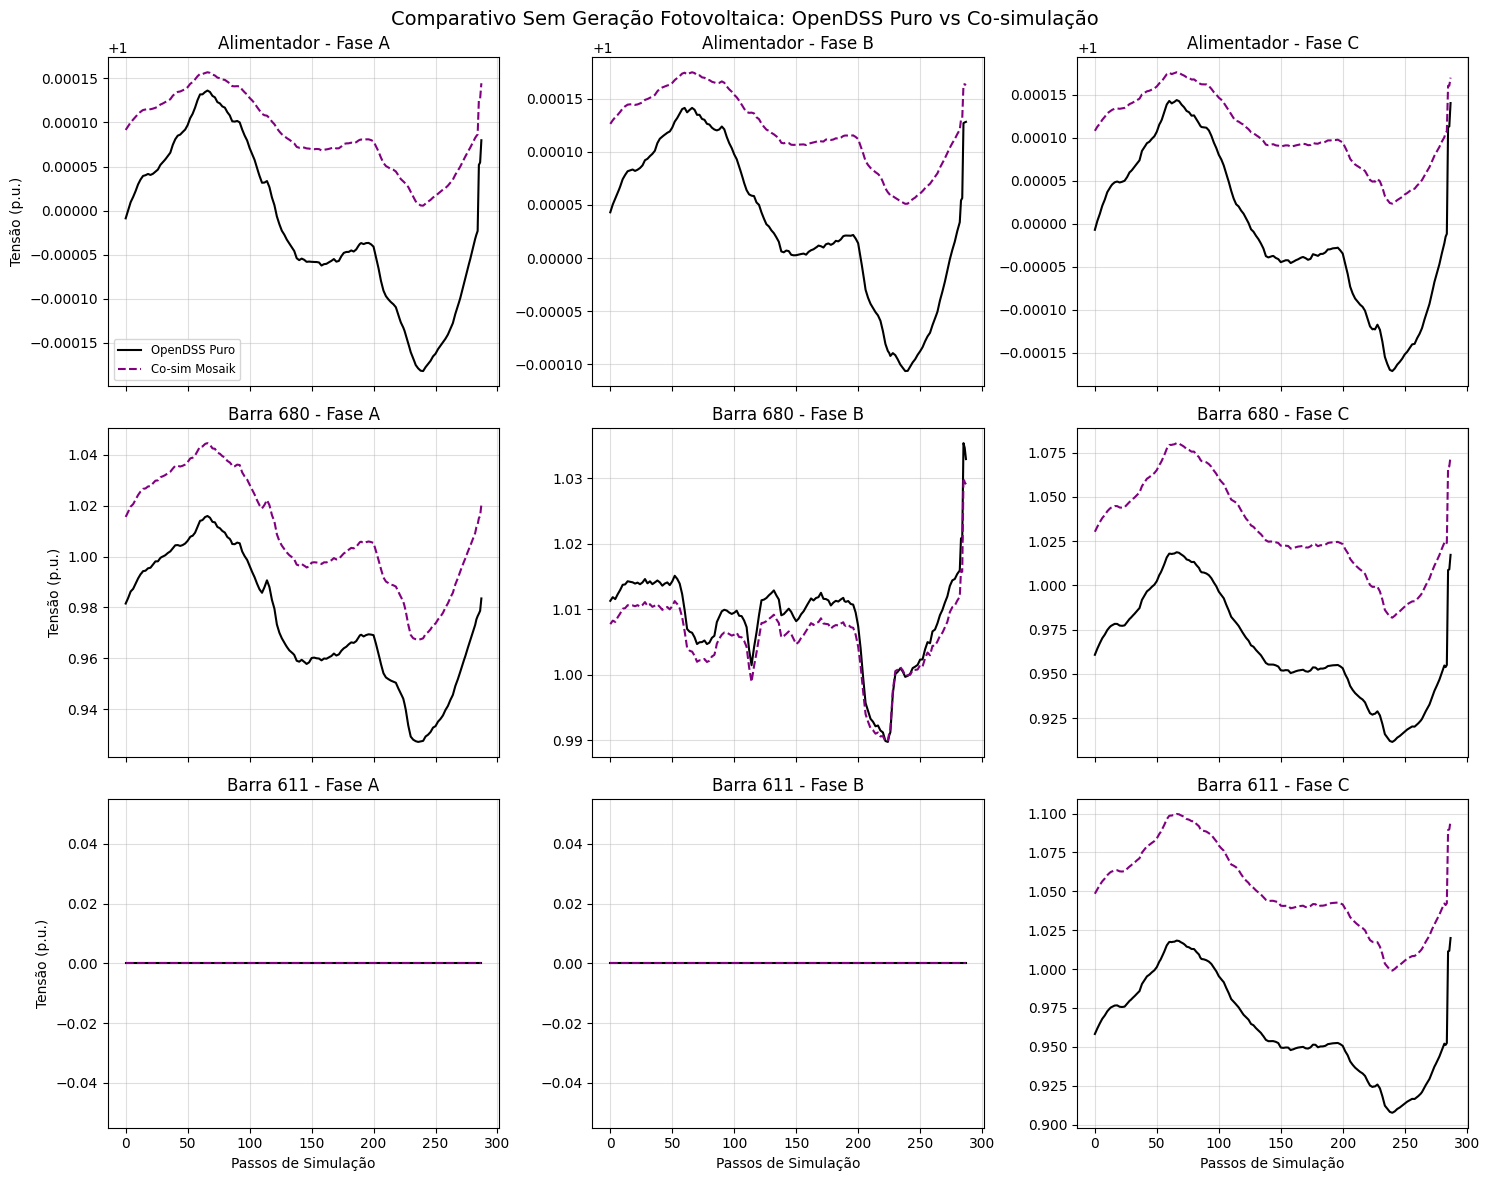

In [8]:
# %% [markdown]
# ## GRID 3x3 - SITUAÇÃO 1: OpenDSS Puro vs Co-simulação Mosaik (Cenário SEM PV)

# %%
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 3, figsize=(15, 12), sharex=True)

# ----------------- LINHA 1: ALIMENTADOR (Feeder) -----------------
# Fase A
axs[0, 0].plot(l650632_va_mag_sem_pv, color='black', linestyle='-', label='OpenDSS Puro')
axs[0, 0].plot(l650632_va_mag_sem_pv_cosim, color='purple', linestyle='--', label='Co-sim Mosaik')
axs[0, 0].set_title('Alimentador - Fase A')
axs[0, 0].set_ylabel('Tensão (p.u.)')
axs[0, 0].legend(loc='best', fontsize='small')
# Fase B
axs[0, 1].plot(l650632_vb_mag_sem_pv, color='black', linestyle='-')
axs[0, 1].plot(l650632_vb_mag_sem_pv_cosim, color='purple', linestyle='--')
axs[0, 1].set_title('Alimentador - Fase B')
# Fase C
axs[0, 2].plot(l650632_vc_mag_sem_pv, color='black', linestyle='-')
axs[0, 2].plot(l650632_vc_mag_sem_pv_cosim, color='purple', linestyle='--')
axs[0, 2].set_title('Alimentador - Fase C')

# ----------------- LINHA 2: BARRA 680 -----------------
# Fase A
axs[1, 0].plot(bus680_va_sem_pv, color='black', linestyle='-')
axs[1, 0].plot(bus680_va_sem_pv_cosim, color='purple', linestyle='--')
axs[1, 0].set_title('Barra 680 - Fase A')
axs[1, 0].set_ylabel('Tensão (p.u.)')
# Fase B
axs[1, 1].plot(bus680_vb_sem_pv, color='black', linestyle='-')
axs[1, 1].plot(bus680_vb_sem_pv_cosim, color='purple', linestyle='--')
axs[1, 1].set_title('Barra 680 - Fase B')
# Fase C
axs[1, 2].plot(bus680_vc_sem_pv, color='black', linestyle='-')
axs[1, 2].plot(bus680_vc_sem_pv_cosim, color='purple', linestyle='--')
axs[1, 2].set_title('Barra 680 - Fase C')

# ----------------- LINHA 3: BARRA 611 -----------------
# Fase A
axs[2, 0].plot(bus611_va_sem_pv, color='black', linestyle='-')
axs[2, 0].plot(bus611_va_sem_pv_cosim, color='purple', linestyle='--')
axs[2, 0].set_title('Barra 611 - Fase A')
axs[2, 0].set_ylabel('Tensão (p.u.)')
axs[2, 0].set_xlabel('Passos de Simulação')
# Fase B
axs[2, 1].plot(bus611_vb_sem_pv, color='black', linestyle='-')
axs[2, 1].plot(bus611_vb_sem_pv_cosim, color='purple', linestyle='--')
axs[2, 1].set_title('Barra 611 - Fase B')
axs[2, 1].set_xlabel('Passos de Simulação')
# Fase C
axs[2, 2].plot(bus611_vc_sem_pv, color='black', linestyle='-')
axs[2, 2].plot(bus611_vc_sem_pv_cosim, color='purple', linestyle='--')
axs[2, 2].set_title('Barra 611 - Fase C')
axs[2, 2].set_xlabel('Passos de Simulação')

for row in axs:
    for ax in row:
        ax.grid(True, alpha=0.4)

plt.suptitle('Comparativo Sem Geração Fotovoltaica: OpenDSS Puro vs Co-simulação', fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

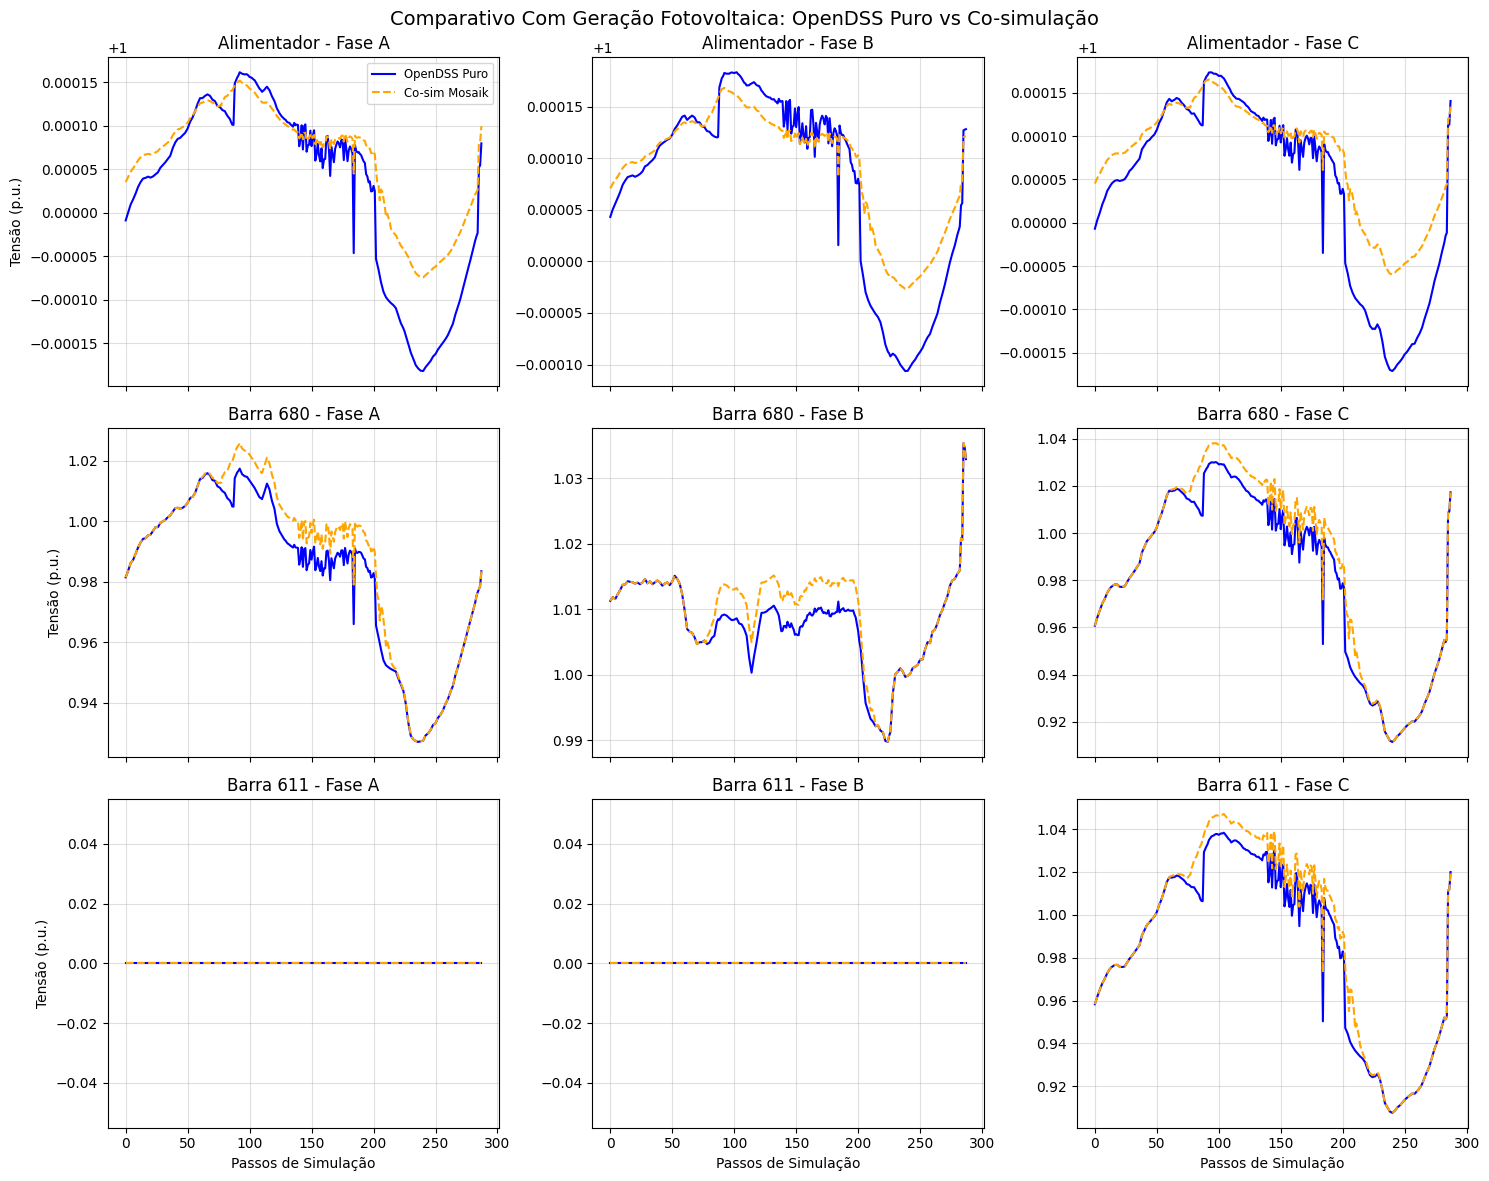

In [9]:
# %% [markdown]
# ## GRID 3x3 - SITUAÇÃO 2: OpenDSS Puro vs Co-simulação Mosaik (Cenário COM PV)

# %%
fig, axs = plt.subplots(3, 3, figsize=(15, 12), sharex=True)

# ----------------- LINHA 1: ALIMENTADOR (Feeder) -----------------
# Fase A
axs[0, 0].plot(l650632_va_mag_pv, color='blue', linestyle='-', label='OpenDSS Puro')
axs[0, 0].plot(l650632_va_mag_pv_cosim, color='orange', linestyle='--', label='Co-sim Mosaik')
axs[0, 0].set_title('Alimentador - Fase A')
axs[0, 0].set_ylabel('Tensão (p.u.)')
axs[0, 0].legend(loc='best', fontsize='small')
# Fase B
axs[0, 1].plot(l650632_vb_mag_pv, color='blue', linestyle='-')
axs[0, 1].plot(l650632_vb_mag_pv_cosim, color='orange', linestyle='--')
axs[0, 1].set_title('Alimentador - Fase B')
# Fase C
axs[0, 2].plot(l650632_vc_mag_pv, color='blue', linestyle='-')
axs[0, 2].plot(l650632_vc_mag_pv_cosim, color='orange', linestyle='--')
axs[0, 2].set_title('Alimentador - Fase C')

# ----------------- LINHA 2: BARRA 680 -----------------
# Fase A
axs[1, 0].plot(bus680_va_pv, color='blue', linestyle='-')
axs[1, 0].plot(bus680_va_pv_cosim, color='orange', linestyle='--')
axs[1, 0].set_title('Barra 680 - Fase A')
axs[1, 0].set_ylabel('Tensão (p.u.)')
# Fase B
axs[1, 1].plot(bus680_vb_pv, color='blue', linestyle='-')
axs[1, 1].plot(bus680_vb_pv_cosim, color='orange', linestyle='--')
axs[1, 1].set_title('Barra 680 - Fase B')
# Fase C
axs[1, 2].plot(bus680_vc_pv, color='blue', linestyle='-')
axs[1, 2].plot(bus680_vc_pv_cosim, color='orange', linestyle='--')
axs[1, 2].set_title('Barra 680 - Fase C')

# ----------------- LINHA 3: BARRA 611 -----------------
# Fase A
axs[2, 0].plot(bus611_va_pv, color='blue', linestyle='-')
axs[2, 0].plot(bus611_va_pv_cosim, color='orange', linestyle='--')
axs[2, 0].set_title('Barra 611 - Fase A')
axs[2, 0].set_ylabel('Tensão (p.u.)')
axs[2, 0].set_xlabel('Passos de Simulação')
# Fase B
axs[2, 1].plot(bus611_vb_pv, color='blue', linestyle='-')
axs[2, 1].plot(bus611_vb_pv_cosim, color='orange', linestyle='--')
axs[2, 1].set_title('Barra 611 - Fase B')
axs[2, 1].set_xlabel('Passos de Simulação')
# Fase C
axs[2, 2].plot(bus611_vc_pv, color='blue', linestyle='-')
axs[2, 2].plot(bus611_vc_pv_cosim, color='orange', linestyle='--')
axs[2, 2].set_title('Barra 611 - Fase C')
axs[2, 2].set_xlabel('Passos de Simulação')

for row in axs:
    for ax in row:
        ax.grid(True, alpha=0.4)

plt.suptitle('Comparativo Com Geração Fotovoltaica: OpenDSS Puro vs Co-simulação', fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

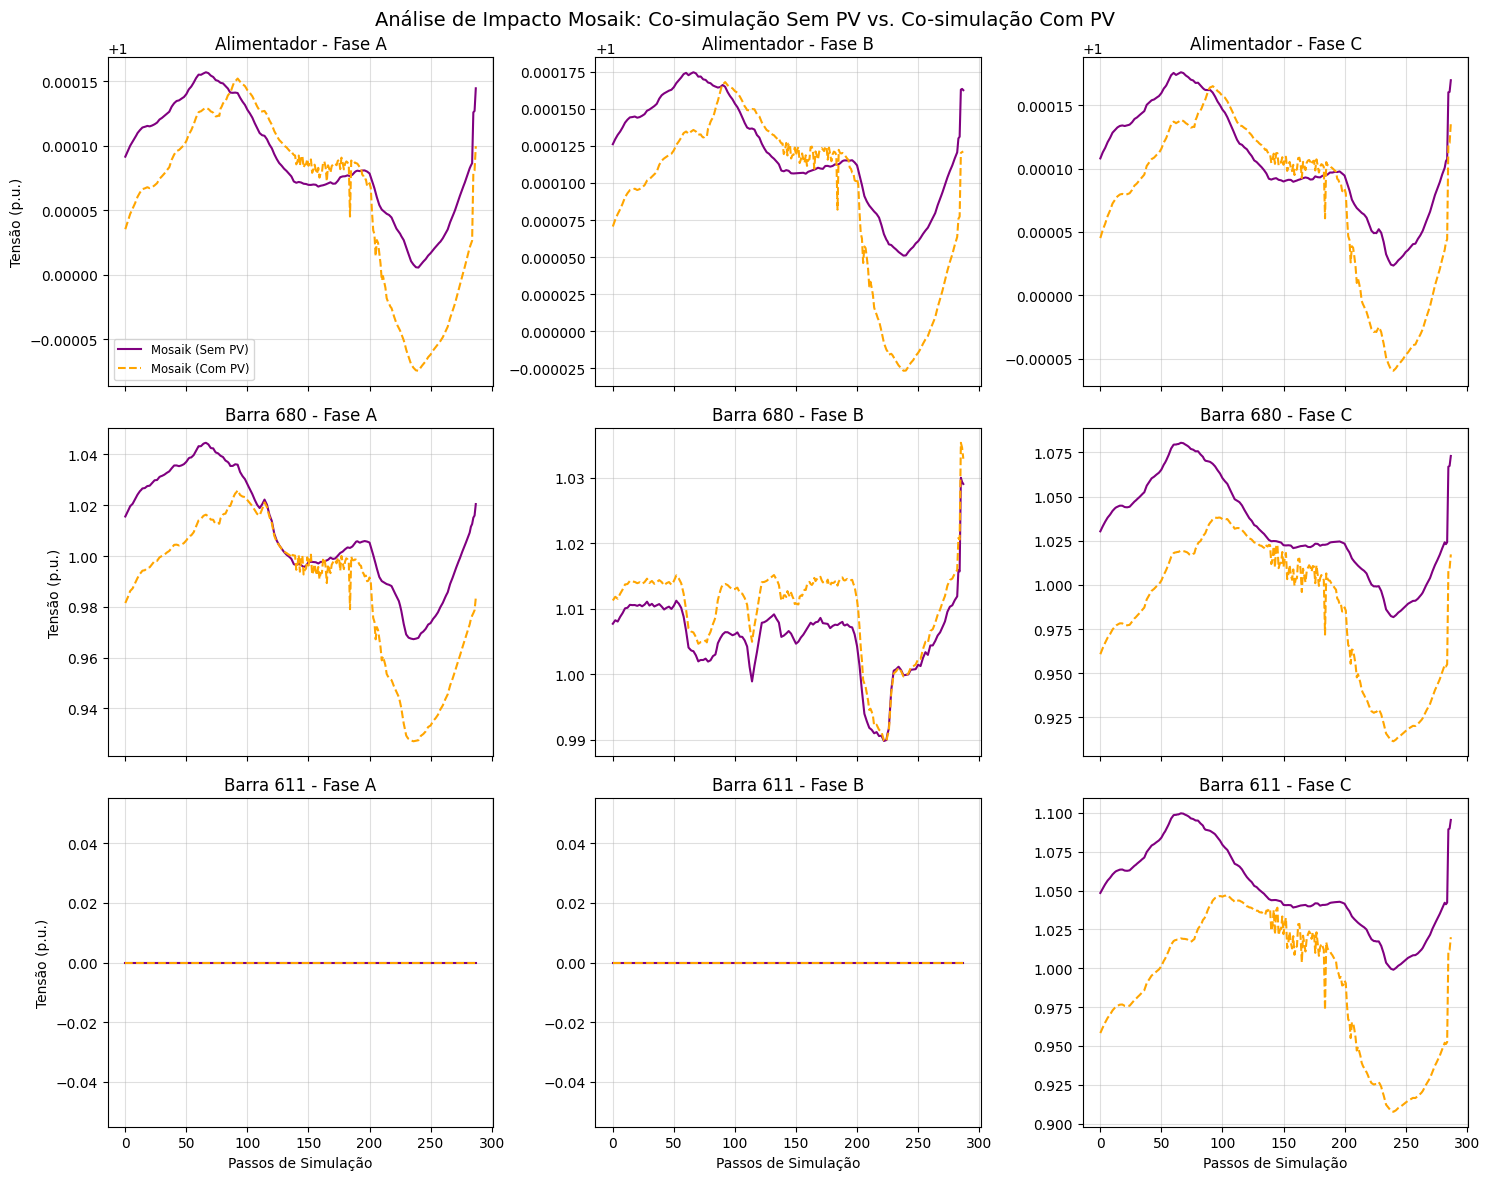

In [10]:
# %% [markdown]
# ## GRID 3x3 - SITUAÇÃO 3: Co-simulação Mosaik (Impacto da inserção de PV: Sem PV vs Com PV)

# %%
fig, axs = plt.subplots(3, 3, figsize=(15, 12), sharex=True)

# ----------------- LINHA 1: ALIMENTADOR (Feeder) -----------------
# Fase A
axs[0, 0].plot(l650632_va_mag_sem_pv_cosim, color='purple', linestyle='-', label='Mosaik (Sem PV)')
axs[0, 0].plot(l650632_va_mag_pv_cosim, color='orange', linestyle='--', label='Mosaik (Com PV)')
axs[0, 0].set_title('Alimentador - Fase A')
axs[0, 0].set_ylabel('Tensão (p.u.)')
axs[0, 0].legend(loc='best', fontsize='small')
# Fase B
axs[0, 1].plot(l650632_vb_mag_sem_pv_cosim, color='purple', linestyle='-')
axs[0, 1].plot(l650632_vb_mag_pv_cosim, color='orange', linestyle='--')
axs[0, 1].set_title('Alimentador - Fase B')
# Fase C
axs[0, 2].plot(l650632_vc_mag_sem_pv_cosim, color='purple', linestyle='-')
axs[0, 2].plot(l650632_vc_mag_pv_cosim, color='orange', linestyle='--')
axs[0, 2].set_title('Alimentador - Fase C')

# ----------------- LINHA 2: BARRA 680 -----------------
# Fase A
axs[1, 0].plot(bus680_va_sem_pv_cosim, color='purple', linestyle='-')
axs[1, 0].plot(bus680_va_pv_cosim, color='orange', linestyle='--')
axs[1, 0].set_title('Barra 680 - Fase A')
axs[1, 0].set_ylabel('Tensão (p.u.)')
# Fase B
axs[1, 1].plot(bus680_vb_sem_pv_cosim, color='purple', linestyle='-')
axs[1, 1].plot(bus680_vb_pv_cosim, color='orange', linestyle='--')
axs[1, 1].set_title('Barra 680 - Fase B')
# Fase C
axs[1, 2].plot(bus680_vc_sem_pv_cosim, color='purple', linestyle='-')
axs[1, 2].plot(bus680_vc_pv_cosim, color='orange', linestyle='--')
axs[1, 2].set_title('Barra 680 - Fase C')

# ----------------- LINHA 3: BARRA 611 -----------------
# Fase A
axs[2, 0].plot(bus611_va_sem_pv_cosim, color='purple', linestyle='-')
axs[2, 0].plot(bus611_va_pv_cosim, color='orange', linestyle='--')
axs[2, 0].set_title('Barra 611 - Fase A')
axs[2, 0].set_ylabel('Tensão (p.u.)')
axs[2, 0].set_xlabel('Passos de Simulação')
# Fase B
axs[2, 1].plot(bus611_vb_sem_pv_cosim, color='purple', linestyle='-')
axs[2, 1].plot(bus611_vb_pv_cosim, color='orange', linestyle='--')
axs[2, 1].set_title('Barra 611 - Fase B')
axs[2, 1].set_xlabel('Passos de Simulação')
# Fase C
axs[2, 2].plot(bus611_vc_sem_pv_cosim, color='purple', linestyle='-')
axs[2, 2].plot(bus611_vc_pv_cosim, color='orange', linestyle='--')
axs[2, 2].set_title('Barra 611 - Fase C')
axs[2, 2].set_xlabel('Passos de Simulação')

for row in axs:
    for ax in row:
        ax.grid(True, alpha=0.4)

plt.suptitle('Análise de Impacto Mosaik: Co-simulação Sem PV vs. Co-simulação Com PV', fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

In [15]:
# ==============================================================================
# ALGORITMO DE CÁLCULO DE MÉTRICAS DE ERRO (PURO PYTHON)
# ==============================================================================

def calcular_metricas_erro(lista_referencia, lista_medicao, amostral=True):
    """
    Calcula RMSE, MAE, desvio padrão dos erros e erro médio entre duas listas.
    """
    ref = list(lista_referencia)
    med = list(lista_medicao)
    
    tamanho = min(len(ref), len(med))
    if tamanho == 0:
        return None, None, None, None
    
    erros = []
    soma_erros_quadrados = 0.0
    soma_erros_absolutos = 0.0
    soma_erros = 0.0
    
    for i in range(tamanho):
        erro = ref[i] - med[i]
        erros.append(erro)
        soma_erros_quadrados += erro ** 2
        soma_erros_absolutos += abs(erro)
        soma_erros += erro
    
    mse = soma_erros_quadrados / tamanho
    rmse = mse ** 0.5
    mae = soma_erros_absolutos / tamanho
    erro_medio = soma_erros / tamanho
    
    if amostral and tamanho > 1:
        divisor = tamanho - 1
    else:
        divisor = tamanho
    
    variancia = sum((e - erro_medio) ** 2 for e in erros) / divisor
    desvio_padrao_erros = variancia ** 0.5
    
    return rmse, mae, desvio_padrao_erros, erro_medio

# ==============================================================================
# DICIONÁRIOS SEPARADOS POR ESTRUTURA (CORRIGIDO: BARRA 611 MONOFÁSICA - FASE C)
# ==============================================================================

erros_alimentador = {
    "Tensão Alimentador - Fase A (Sem PV) [pu]": (l650632_va_mag_sem_pv, l650632_va_mag_sem_pv_cosim),
    "Tensão Alimentador - Fase B (Sem PV) [pu]": (l650632_vb_mag_sem_pv, l650632_vb_mag_sem_pv_cosim),
    "Tensão Alimentador - Fase C (Sem PV) [pu]": (l650632_vc_mag_sem_pv, l650632_vc_mag_sem_pv_cosim),
    "Tensão Alimentador - Fase A (Com PV) [pu]": (l650632_va_mag_pv, l650632_va_mag_pv_cosim),
    "Tensão Alimentador - Fase B (Com PV) [pu]": (l650632_vb_mag_pv, l650632_vb_mag_pv_cosim),
    "Tensão Alimentador - Fase C (Com PV) [pu]": (l650632_vc_mag_pv, l650632_vc_mag_pv_cosim),
}

erros_barra680 = {
    "Tensão Barra 680 - Fase A (Sem PV) [pu]": (bus680_va_sem_pv, bus680_va_sem_pv_cosim),
    "Tensão Barra 680 - Fase B (Sem PV) [pu]": (bus680_vb_sem_pv, bus680_vb_sem_pv_cosim),
    "Tensão Barra 680 - Fase C (Sem PV) [pu]": (bus680_vc_sem_pv, bus680_vc_sem_pv_cosim),
    "Tensão Barra 680 - Fase A (Com PV) [pu]": (bus680_va_pv, bus680_va_pv_cosim),
    "Tensão Barra 680 - Fase B (Com PV) [pu]": (bus680_vb_pv, bus680_vb_pv_cosim),
    "Tensão Barra 680 - Fase C (Com PV) [pu]": (bus680_vc_pv, bus680_vc_pv_cosim),
}

# Apenas Fase C existe na Barra 611
erros_barra611 = {
    "Tensão Barra 611 - Fase C (Sem PV) [pu]": (bus611_vc_sem_pv, bus611_vc_sem_pv_cosim),
    "Tensão Barra 611 - Fase C (Com PV) [pu]": (bus611_vc_pv, bus611_vc_pv_cosim),
}


# ==============================================================================
# IMPRESSÃO EM FORMATO DE TABELA NATIVA DO MARKDOWN
# ==============================================================================

# Cabeçalho Geral da Tabela
print("| Grandeza Analisada | RMSE | MAE | Desv. Padrão | Erro Médio |")
print("| :--- | :---: | :---: | :---: | :---: |")

# --- PARTE 1: ALIMENTADOR ---
print("| **PARTE 1: ALIMENTADOR 650-632** | | | | |")
for nome, (ref, med) in erros_alimentador.items():
    rmse, mae, desv, medio = calcular_metricas_erro(ref, med)
    if rmse is not None:
        print(f"| {nome} | {rmse:.6f} | {mae:.6f} | {desv:.6f} | {medio:.6f} |")

# --- PARTE 2: BARRA 680 ---
print("| **PARTE 2: BARRA 680** | | | | |")
for nome, (ref, med) in erros_barra680.items():
    rmse, mae, desv, medio = calcular_metricas_erro(ref, med)
    if rmse is not None:
        print(f"| {nome} | {rmse:.6f} | {mae:.6f} | {desv:.6f} | {medio:.6f} |")

# --- PARTE 3: BARRA 611 (Monofásica) ---
print("| **PARTE 3: BARRA 611 (Monofásica - Fase C)** | | | | |")
for nome, (ref, med) in erros_barra611.items():
    rmse, mae, desv, medio = calcular_metricas_erro(ref, med)
    if rmse is not None:
        print(f"| {nome} | {rmse:.6f} | {mae:.6f} | {desv:.6f} | {medio:.6f} |")

| Grandeza Analisada | RMSE | MAE | Desv. Padrão | Erro Médio |
| :--- | :---: | :---: | :---: | :---: |
| **PARTE 1: ALIMENTADOR 650-632** | | | | |
| Tensão Alimentador - Fase A (Sem PV) [pu] | 0.000115 | 0.000104 | 0.000048 | -0.000104 |
| Tensão Alimentador - Fase B (Sem PV) [pu] | 0.000096 | 0.000088 | 0.000037 | -0.000088 |
| Tensão Alimentador - Fase C (Sem PV) [pu] | 0.000122 | 0.000112 | 0.000047 | -0.000112 |
| Tensão Alimentador - Fase A (Com PV) [pu] | 0.000052 | 0.000037 | 0.000040 | -0.000033 |
| Tensão Alimentador - Fase B (Com PV) [pu] | 0.000039 | 0.000029 | 0.000035 | -0.000017 |
| Tensão Alimentador - Fase C (Com PV) [pu] | 0.000054 | 0.000039 | 0.000041 | -0.000036 |
| **PARTE 2: BARRA 680** | | | | |
| Tensão Barra 680 - Fase A (Sem PV) [pu] | 0.035433 | 0.035246 | 0.003634 | -0.035246 |
| Tensão Barra 680 - Fase B (Sem PV) [pu] | 0.003164 | 0.002948 | 0.001235 | 0.002914 |
| Tensão Barra 680 - Fase C (Sem PV) [pu] | 0.067823 | 0.067734 | 0.003475 | -0.067734 |
| T